<a href="https://colab.research.google.com/github/khadkaabishek/Machine-Learning-Labs/blob/main/logistic_regression_qn3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Lab3/diabetes.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
X = df.drop(['Outcome'],axis=1)
y=df['Outcome']

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [8]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [11]:
y_pred = model.predict(X_test.values)
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       206
           1       0.65      0.65      0.65       102

    accuracy                           0.77       308
   macro avg       0.74      0.74      0.74       308
weighted avg       0.77      0.77      0.77       308



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt


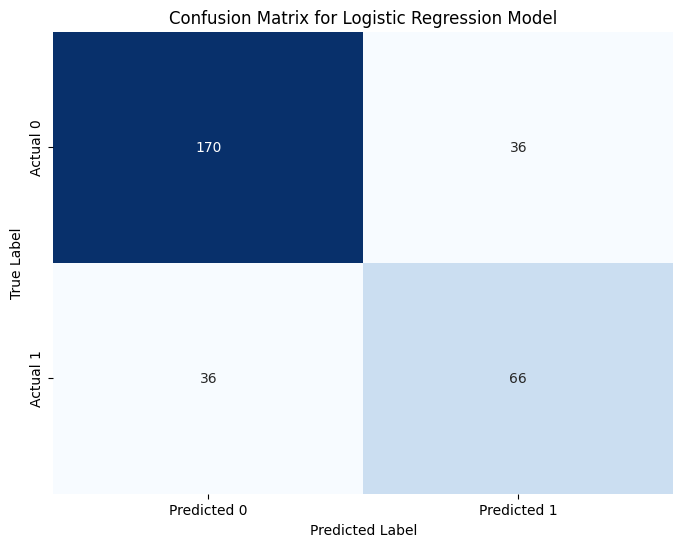

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

Now, let's apply this sigmoid function to the decision scores from your `LogisticRegression` model to get the predicted probabilities.

Let's plot the sigmoid function to visualize how it transforms the decision scores into probabilities. We'll also mark some of the actual `decision_scores` and `predicted_probabilities` on this plot.

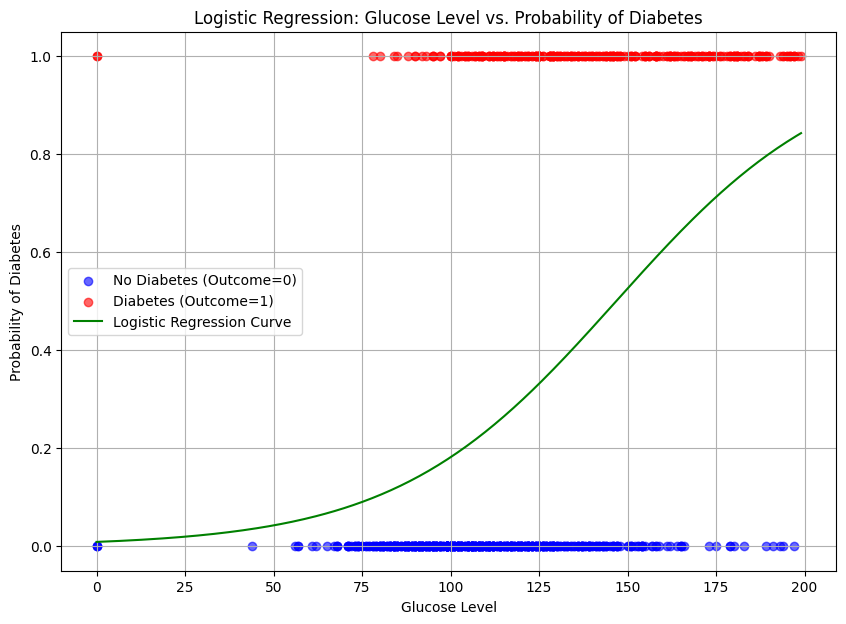

In [20]:
import numpy as np

plt.figure(figsize=(10, 7))

# Plot actual data points for 'Glucose' vs 'Outcome'
plt.scatter(df['Glucose'][df['Outcome'] == 0], df['Outcome'][df['Outcome'] == 0],
            color='blue', label='No Diabetes (Outcome=0)', alpha=0.6)
plt.scatter(df['Glucose'][df['Outcome'] == 1], df['Outcome'][df['Outcome'] == 1],
            color='red', label='Diabetes (Outcome=1)', alpha=0.6)

# Generate a range of 'Glucose' values for plotting the logistic regression curve
X_range_glucose = np.linspace(df['Glucose'].min(), df['Glucose'].max(), 300).reshape(-1, 1)

# Create a DataFrame for prediction, filling other features with their mean values from X_train
# This is an approximation for visualization purposes in 2D
mean_features_values = X_train.mean().values.reshape(1, -1)

# Create a temporary DataFrame with mean values
X_plot_model_df = pd.DataFrame(np.tile(mean_features_values, (len(X_range_glucose), 1)), columns=X_train.columns)

# Update the 'Glucose' column with the varying X_range_glucose values
X_plot_model_df['Glucose'] = X_range_glucose.flatten()

# Predict probabilities for the generated X_plot_model_df
y_prob_range = model.predict_proba(X_plot_model_df)[:, 1]

# Plot the logistic regression curve
plt.plot(X_range_glucose, y_prob_range, color='green', linestyle='-', label='Logistic Regression Curve')

plt.xlabel('Glucose Level')
plt.ylabel('Probability of Diabetes')
plt.title('Logistic Regression: Glucose Level vs. Probability of Diabetes')
plt.legend()
plt.grid(True)
plt.show()